In [1]:
# Minimal imports
from ladder.data import get_data # Needed to grab data
from ladder.scripts import CrossConditionWorkflow # Our workflow object to run the cross-conditional model
import umap, torch, pyro # To set seeds + umaps
import torch.optim as opt # For defining out optimizer


# For plotting
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from umap import UMAP
import pickle

# For data loading
import anndata as ad
import scanpy as sc

# Set up plots
import os
os.makedirs('plots', exist_ok=True)

# Reconstruction

In [20]:
# Minimal imports
from ladder.scripts import (
    CrossConditionWorkflow,
)  # Our workflow object to run the cross-conditional model
from ladder.data import distrib_dataset, get_data  # Explicit dataset setting

import anndata as ad
import pandas as pd
import numpy as np
import scanpy as sc
import os, sys, re, pickle


setname, model, subtype = (
    "mascharak",
    "Patches",
    "Fibroblast"
)
print(f"Running: {setname}, {model}")


k = 5

results = {}



for num_iter in range(k):
    match setname:
        case "ay":
            # Load the anndata object
            anndata = ad.read_h5ad("data/vu_2022_ay_wh.h5ad")
            anndata.layers["normalized"] = anndata.X

            # Find/subset HVGs & swap to raw counts
            sc.pp.highly_variable_genes(
                anndata, n_top_genes=3000, batch_key="sample"
            )

            anndata = anndata[:, anndata.var["highly_variable"]]
            anndata.X = anndata.layers["counts"]

            factors = ["time", "age", "broad_type"]
            batch_key = "sample"

        case "mascharak":
            # Load the anndata object
            anndata = ad.read_h5ad("data/mascharak_2022_tn_wh.h5ad")
            anndata.layers["normalized"] = anndata.X

            # Find/subset HVGs & swap to raw counts
            sc.pp.highly_variable_genes(anndata, n_top_genes=3000)

            anndata = anndata[:, anndata.var["highly_variable"]]
            anndata.X = anndata.layers["counts"]

            factors = ["time", "treatment", "broad_type"]
            batch_key = None

    # Get workflow
    seed = int([re.match(fr'{model}_{setname}_{num_iter}_(\d+)', elem) for elem in os.listdir(fr'model_exps_recon/repeats/{model}_{setname}') if re.match(fr'{model}_{setname}_{num_iter}_(\d+)', elem) is not None][0][1])
    print(f"Seed is now {seed}")
    workflow = CrossConditionWorkflow(anndata, verbose=True, random_seed=seed)

    # Call prep_model once to load data initially
    workflow.prep_model(
        factors,
        batch_key=batch_key,
        cell_type_label_key="broad_type",
        model_type=model,
        optim_args={
            "lr": 1e-3,
        },
    )

    workflow.load_model(f'model_exps_recon/repeats/{model}_{setname}/{model}_{setname}_{num_iter}')


    res = workflow.evaluate_reconstruction(cell_type=subtype)

    for key, val in res.items():
        if key not in results.keys():
            results[key] = val

        else:
            results[key] = results[key] + val

    

# Organize and print for easy pasting
printer = []

for key, val in results.items():
    mean, std = np.round(np.mean([val[i] for i in range(0,len(val),2)]),3), np.round(np.mean([val[i] for i in range(1,len(val),2)]),3)
    printer.append(f"${mean} \\pm {std}$")


if subtype == None:
    subtype = "All"

with open(f'model_exps_recon/res/res_{model}_{setname}_{subtype}', 'wb') as handle:
    pickle.dump(printer, handle, protocol=pickle.HIGHEST_PROTOCOL)


print(" & ".join(printer))

Running: mascharak, Patches
Seed is now 428451


/insomnia001/depts/morpheus/users/ob2391/miniforge3/envs/csvae/lib/python3.12/site-packages/ladder/data/real_data.py:299: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  anndat.obs[colname] = anndat.obs[colname].astype("category")


Initialized workflow to run cross-condition model.

Condition classes : ['time', 'treatment', 'broad_type']
Number of attributes per class : [3, 2, 9]

Initialized Patches model.
Model arguments: {'reconstruction': 'ZINB', 'batch_correction': False, 'scale_factor': 2.6041666666666666e-06, 'num_labels': 14, 'len_attrs': [3, 2, 9]}

Optimizer args parsed successfully. Final arguments: {'optimizer': <class 'torch.optim.adam.Adam'>, 'optim_args': {'lr': 0.001, 'eps': 0.01, 'betas': (0.9, 0.999)}, 'gamma': 1, 'milestones': [10000000000.0]}
Subsetting test to Fibroblast cells
Calculating RMSE ...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:04<00:00,  1.17it/s]


Calculating Profile Correlation ...


...

Calculating 2-Sliced Wasserstein ...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:09<00:00,  1.96s/it]


Calculating Chamfer Discrepancy ...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 1347.00it/s]

Results
RMSE : 5.634 +- 1.111
Profile Correlation : 0.983 +- 0.001
2-Sliced Wasserstein : 4.744 +- 0.877
Chamfer Discrepancy : 101.495 +- 9.325
$5.867 \pm 1.012$ & $0.981 \pm 0.004$ & $5.965 \pm 0.849$ & $116.705 \pm 12.38$


# Transfers

In [249]:
# Minimal imports
from ladder.scripts import (
    CrossConditionWorkflow,
)  # Our workflow object to run the cross-conditional model
from ladder.data import distrib_dataset, get_data  # Explicit dataset setting
from ladder.scripts.metrics import _get_subset, _get_rmse_n_to_1, _get_corr_n_to_1, _get_chamf_n_to_1, _get_sliced_wasserstein_n_to_1, _get_normalized_profile, get_normalized_profile get_reproduction_error


import anndata as ad
import pandas as pd
import numpy as np
import scanpy as sc
import os, sys, re, pickle

setname, model, subtype = (
    "mascharak",
    "Patches",
    "Fibroblast"
)

print(f"Running: {setname}, {model}")

k = 5

results = {}


for num_iter in range(k):
    match setname:
        case "ay":
            # Load the anndata object
            anndata = ad.read_h5ad("data/vu_2022_ay_wh.h5ad")
            anndata.layers["normalized"] = anndata.X

            # Find/subset HVGs & swap to raw counts
            sc.pp.highly_variable_genes(
                anndata, n_top_genes=3000, batch_key="sample"
            )

            anndata = anndata[:, anndata.var["highly_variable"]]
            anndata.X = anndata.layers["counts"]

            factors = ["time", "age", "broad_type"]
            batch_key = "sample"

        case "mascharak":
            # Load the anndata object
            anndata = ad.read_h5ad("data/mascharak_2022_tn_wh.h5ad")
            anndata.layers["normalized"] = anndata.X

            # Find/subset HVGs & swap to raw counts
            sc.pp.highly_variable_genes(anndata, n_top_genes=3000)

            anndata = anndata[:, anndata.var["highly_variable"]]
            anndata.X = anndata.layers["counts"]

            factors = ["time", "treatment", "broad_type"]
            batch_key = None

    # Get workflow
    seed = int([re.match(fr'{model}_{setname}_{num_iter}_(\d+)', elem) for elem in os.listdir(fr'model_exps_recon/repeats/{model}_{setname}') if re.match(fr'{model}_{setname}_{num_iter}_(\d+)', elem) is not None][0][1])
    print(f"Seed is now {seed}")
    workflow = CrossConditionWorkflow(anndata, verbose=True, random_seed=seed)

    # Call prep_model once to load data initially
    workflow.prep_model(
        factors,
        batch_key=batch_key,
        cell_type_label_key="broad_type",
        model_type=model,
        optim_args={
            "lr": 1e-3,
        },
    )

    workflow.load_model(f'model_exps_recon/repeats/{model}_{setname}/{model}_{setname}_{num_iter}')


    match model:
        case 'Patches':
            match setname:
                case 'ay':
                    res = workflow.evaluate_transfer(source=f'time_0DPW - age_Aged - broad_type_{subtype}', target=f'time_4DPW - age_Aged - broad_type_{subtype}')
                case 'mascharak':
                    res = workflow.evaluate_transfer(source=f'time_POD7 - treatment_PBS-treated - broad_type_{subtype}', target=f'time_POD14 - treatment_PBS-treated - broad_type_{subtype}')

        case 'SCANVI':
            match setname:
                case 'ay':
                    res = workflow.evaluate_transfer(source=f'0DPW_Aged_{subtype}', target=f'4DPW_Aged_{subtype}')
                case 'mascharak':
                    res = workflow.evaluate_transfer(source=f'POD7_PBS-treated_{subtype}', target=f'POD14_PBS-treated_{subtype}')


        case 'SCVI':
            match setname:
                case 'ay':
                    source, target = f'time_0DPW - age_Aged - broad_type_{subtype}', f'time_4DPW - age_Aged - broad_type_{subtype}'
                case 'mascharak':
                    source, target = f'time_POD7 - treatment_PBS-treated - broad_type_{subtype}', f'time_POD14 - treatment_PBS-treated - broad_type_{subtype}'

            # Transfer
            res = {}
            source_t, target_t = workflow.levels[source], workflow.levels[target]
            
            # Grab source / target means
            source_set, target_set = _get_subset(workflow.test_set, torch.tensor(source_t)), _get_subset(workflow.train_set, torch.tensor(target_t))
            source_mean, target_mean = workflow.model.zl_encoder(source_set[:][0].cpu())[0].mean(0), workflow.model.zl_encoder(target_set[:][0].cpu())[0].mean(0)
            
            for metric in ["rmse", "corr", "swd", "chamfer"]:
            
                preds = []
            
            
                for i in trange(5):
            
                    # Encode the data
                    source_set, target_set = _get_subset(workflow.test_set, torch.tensor(source_t)), _get_subset(workflow.test_set, torch.tensor(target_t))
                    z_loc, z_scale, l_loc, l_scale = workflow.model.zl_encoder(source_set[:][0].cpu())
            
                    l_enc = dist.LogNormal(l_loc, l_scale).sample()
                    z_enc = dist.Normal(z_loc, z_scale).sample()
            
            
                    # Perform vector arithmetic in latent space
                    z_enc = z_enc - source_mean + target_mean
            
                    # Batch correction
                    if workflow.batch_correction:
                        z_enc = torch.cat([z_enc, source_set[:][0][:,-1].view(-1,1)], dim=-1)            
            
                    # Decode
                    theta = dict(pyro.get_param_store())["inverse_dispersion"].detach()
            
                    gate_logits, mu = workflow.model.x_decoder(z_enc)
            
                    nb_logits = (l_enc * mu + workflow.model.epsilon).log() - (theta.cpu() + workflow.model.epsilon).log()
                    x_dist = dist.ZeroInflatedNegativeBinomial(gate_logits=gate_logits, total_count=theta,
                                                      logits=nb_logits, validate_args=False)
            
                    x_rec =  x_dist.sample()
            
                    preds.append(x_rec)
            
            
                preds = torch.stack(preds).cpu()
                profiles = torch.stack([_get_normalized_profile(s) for s in preds]).cpu()
            
            
                match metric: # Add different case for each key
                    case "rmse":
                        _metric_func = _get_rmse_n_to_1
            
                    case "corr":
                        _metric_func = _get_corr_n_to_1
            
                    case "chamfer":
                        _metric_func = _get_chamf_n_to_1
            
                    case "swd":
                        _metric_func = _get_sliced_wasserstein_n_to_1
                    
            
                match metric:
            
                    case "rmse" | "corr": # Add profile metrics here 
                        mean_profile = get_normalized_profile(workflow.test_set, target=torch.tensor(target_t), batched=workflow.batch_correction)
                        preds_mean_error, preds_mean_var = _metric_func(profiles, mean_profile)
            
                    case "chamfer" | "swd": # Add cloud metrics here
                        orig = _get_subset(workflow.test_set, torch.tensor(target_t))[:][0]
            
                        if workflow.batch_correction:
                            orig = orig[..., :-1]
                        
                        preds_mean_error, preds_mean_var = _metric_func(preds, orig)
                
                
                res[workflow.METRICS_REG[metric]] = [
                    np.round(preds_mean_error, 3),
                    np.round(preds_mean_var, 3),
                ]                   

            

    for key, val in res.items():
        if key not in results.keys():
            results[key] = val

        else:
            results[key] = results[key] + val

    

# Organize and print for easy pasting
printer = []

for key, val in results.items():
    mean, std = np.round(np.mean([val[i] for i in range(0,len(val),2)]),3), np.round(np.mean([val[i] for i in range(1,len(val),2)]),3)
    printer.append(f"${mean} \\pm {std}$")


if subtype == None:
    subtype = "All"

with open(f'model_exps_recon/res_transfer/res_{model}_{setname}_{subtype}', 'wb') as handle:
    pickle.dump(printer, handle, protocol=pickle.HIGHEST_PROTOCOL)


print(" & ".join(printer))

Running: mascharak, Patches
Seed is now 428451
Initialized workflow to run cross-condition model.

Condition classes : ['time', 'treatment', 'broad_type']
Number of attributes per class : [3, 2, 9]


/insomnia001/depts/morpheus/users/ob2391/miniforge3/envs/csvae/lib/python3.12/site-packages/ladder/data/real_data.py:299: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  anndat.obs[colname] = anndat.obs[colname].astype("category")



Initialized Patches model.
Model arguments: {'reconstruction': 'ZINB', 'batch_correction': False, 'scale_factor': 2.6041666666666666e-06, 'num_labels': 14, 'len_attrs': [3, 2, 9]}

Optimizer args parsed successfully. Final arguments: {'optimizer': <class 'torch.optim.adam.Adam'>, 'optim_args': {'lr': 0.001, 'eps': 0.01, 'betas': (0.9, 0.999)}, 'gamma': 1, 'milestones': [10000000000.0]}
Evaluating mapping...
Source: time_POD7 - treatment_PBS-treated - broad_type_Fibroblast --> Target: time_POD14 - treatment_PBS-treated - broad_type_Fibroblast
Calculating RMSE ...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 38.00it/s]


Calculating Profile Correlation ...


...

Calculating 2-Sliced Wasserstein ...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:15<00:00,  1.52s/it]


Calculating Chamfer Discrepancy ...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 2868.68it/s]

Results
RMSE : 11.264 +- 3.038
Profile Correlation : 0.908 +- 0.028
2-Sliced Wasserstein : 7.917 +- 0.902
Chamfer Discrepancy : 156.458 +- 46.384
$14.253 \pm 3.058$ & $0.86 \pm 0.035$ & $10.211 \pm 1.283$ & $185.852 \pm 33.098$


# Table

In [2]:
# Compiled results from runs
metrics_res = {
    'Vu': {
        'All': {
            'scVI': None ,
            'scANVI': None ,
            'Patches': None ,
        },
        'Fibroblast': {
            'scVI': None ,
            'scANVI': None ,
            'Patches': None ,
        },
        'Keratinocyte': {
            'scVI': None ,
            'scANVI': None ,
            'Patches': None ,
        },
        'Macrophage':{
            'scVI': None ,
            'scANVI': None ,
            'Patches': None ,
        },
    },

    'Mascharak': {
        'All': {
            'scVI': None ,
            'scANVI': None ,
            'Patches': None ,
        },
        'Fibroblast': {
            'scVI': None ,
            'scANVI': None ,
            'Patches': None ,
        },
        'Macrophage': {
            'scVI': None ,
            'scANVI': None ,
            'Patches': None ,
        },
        'T Cell':{
            'scVI': None ,
            'scANVI': None ,
            'Patches': None ,
        },
    },
}

metrics_res_transfer = {
    'Vu': {
        'Fibroblast': {
            'scVI': None ,
            'scANVI': None ,
            'Patches': None ,
        },
        'Keratinocyte': {
            'scVI': None ,
            'scANVI': None ,
            'Patches': None ,
        },
        'Macrophage':{
            'scVI': None ,
            'scANVI': None ,
            'Patches': None ,
        },
    },

    'Mascharak': {
        'Fibroblast': {
            'scVI': None ,
            'scANVI': None ,
            'Patches': None ,
        },
        'Macrophage': {
            'scVI': None ,
            'scANVI': None ,
            'Patches': None ,
        },
        'T Cell':{
            'scVI': None ,
            'scANVI': None ,
            'Patches': None ,
        },
    },
}



for setname in ['ay', 'mascharak']:
    match setname :
        case 'ay':
            name = 'Vu'
            ctypes = ['All', 'Fibroblast', 'Keratinocyte', 'Macrophage']

        case 'mascharak':
            name = 'Mascharak'
            ctypes = ['All', 'Fibroblast', 'Macrophage', 'T Cell']


    for ctype in ctypes:
        for model in ['Patches', 'SCVI', 'SCANVI']:
            with open(f'model_exps_recon/res/res_{model}_{setname}_{ctype}', 'rb') as handle:
                f = pickle.load(handle)
                
                if model in ['SCVI', 'SCANVI']:
                    modelname = model[:2].lower() + model[2:]
                else:
                    modelname = model

                metrics_res[name][ctype][modelname] = f



for setname in ['ay', 'mascharak']:
    match setname :
        case 'ay':
            name = 'Vu'
            ctypes = ['Fibroblast', 'Keratinocyte', 'Macrophage']

        case 'mascharak':
            name = 'Mascharak'
            ctypes = ['Fibroblast', 'Macrophage', 'T Cell']


    for ctype in ctypes:
        for model in ['Patches', 'SCVI', 'SCANVI']:
            with open(f'model_exps_recon/res_transfer/res_{model}_{setname}_{ctype}', 'rb') as handle:
                f = pickle.load(handle)
                
                if model in ['SCVI', 'SCANVI']:
                    modelname = model[:2].lower() + model[2:]
                else:
                    modelname = model

                metrics_res_transfer[name][ctype][modelname] = f


metrics_res_transfer

{'Vu': {'Fibroblast': {'scVI': ['$6.299 \\pm 0.274$',
    '$0.989 \\pm 0.001$',
    '$4.682 \\pm 0.256$',
    '$66.676 \\pm 2.842$'],
   'scANVI': ['$38.148 \\pm 0.336$',
    '$0.53 \\pm 0.008$',
    '$11.241 \\pm 0.087$',
    '$220.985 \\pm 8.09$'],
   'Patches': ['$8.159 \\pm 0.623$',
    '$0.986 \\pm 0.002$',
    '$6.011 \\pm 0.667$',
    '$76.208 \\pm 6.875$']},
  'Keratinocyte': {'scVI': ['$7.783 \\pm 0.288$',
    '$0.976 \\pm 0.001$',
    '$10.563 \\pm 0.283$',
    '$141.194 \\pm 18.798$'],
   'scANVI': ['$42.602 \\pm 0.38$',
    '$0.443 \\pm 0.01$',
    '$12.723 \\pm 1.056$',
    '$293.448 \\pm 51.1$'],
   'Patches': ['$9.301 \\pm 0.366$',
    '$0.972 \\pm 0.002$',
    '$13.761 \\pm 0.491$',
    '$265.743 \\pm 24.242$']},
  'Macrophage': {'scVI': ['$6.388 \\pm 0.492$',
    '$0.983 \\pm 0.002$',
    '$12.706 \\pm 1.384$',
    '$269.47 \\pm 27.581$'],
   'scANVI': ['$33.958 \\pm 1.131$',
    '$0.571 \\pm 0.025$',
    '$18.068 \\pm 0.197$',
    '$481.851 \\pm 9.175$'],
   'Patches'

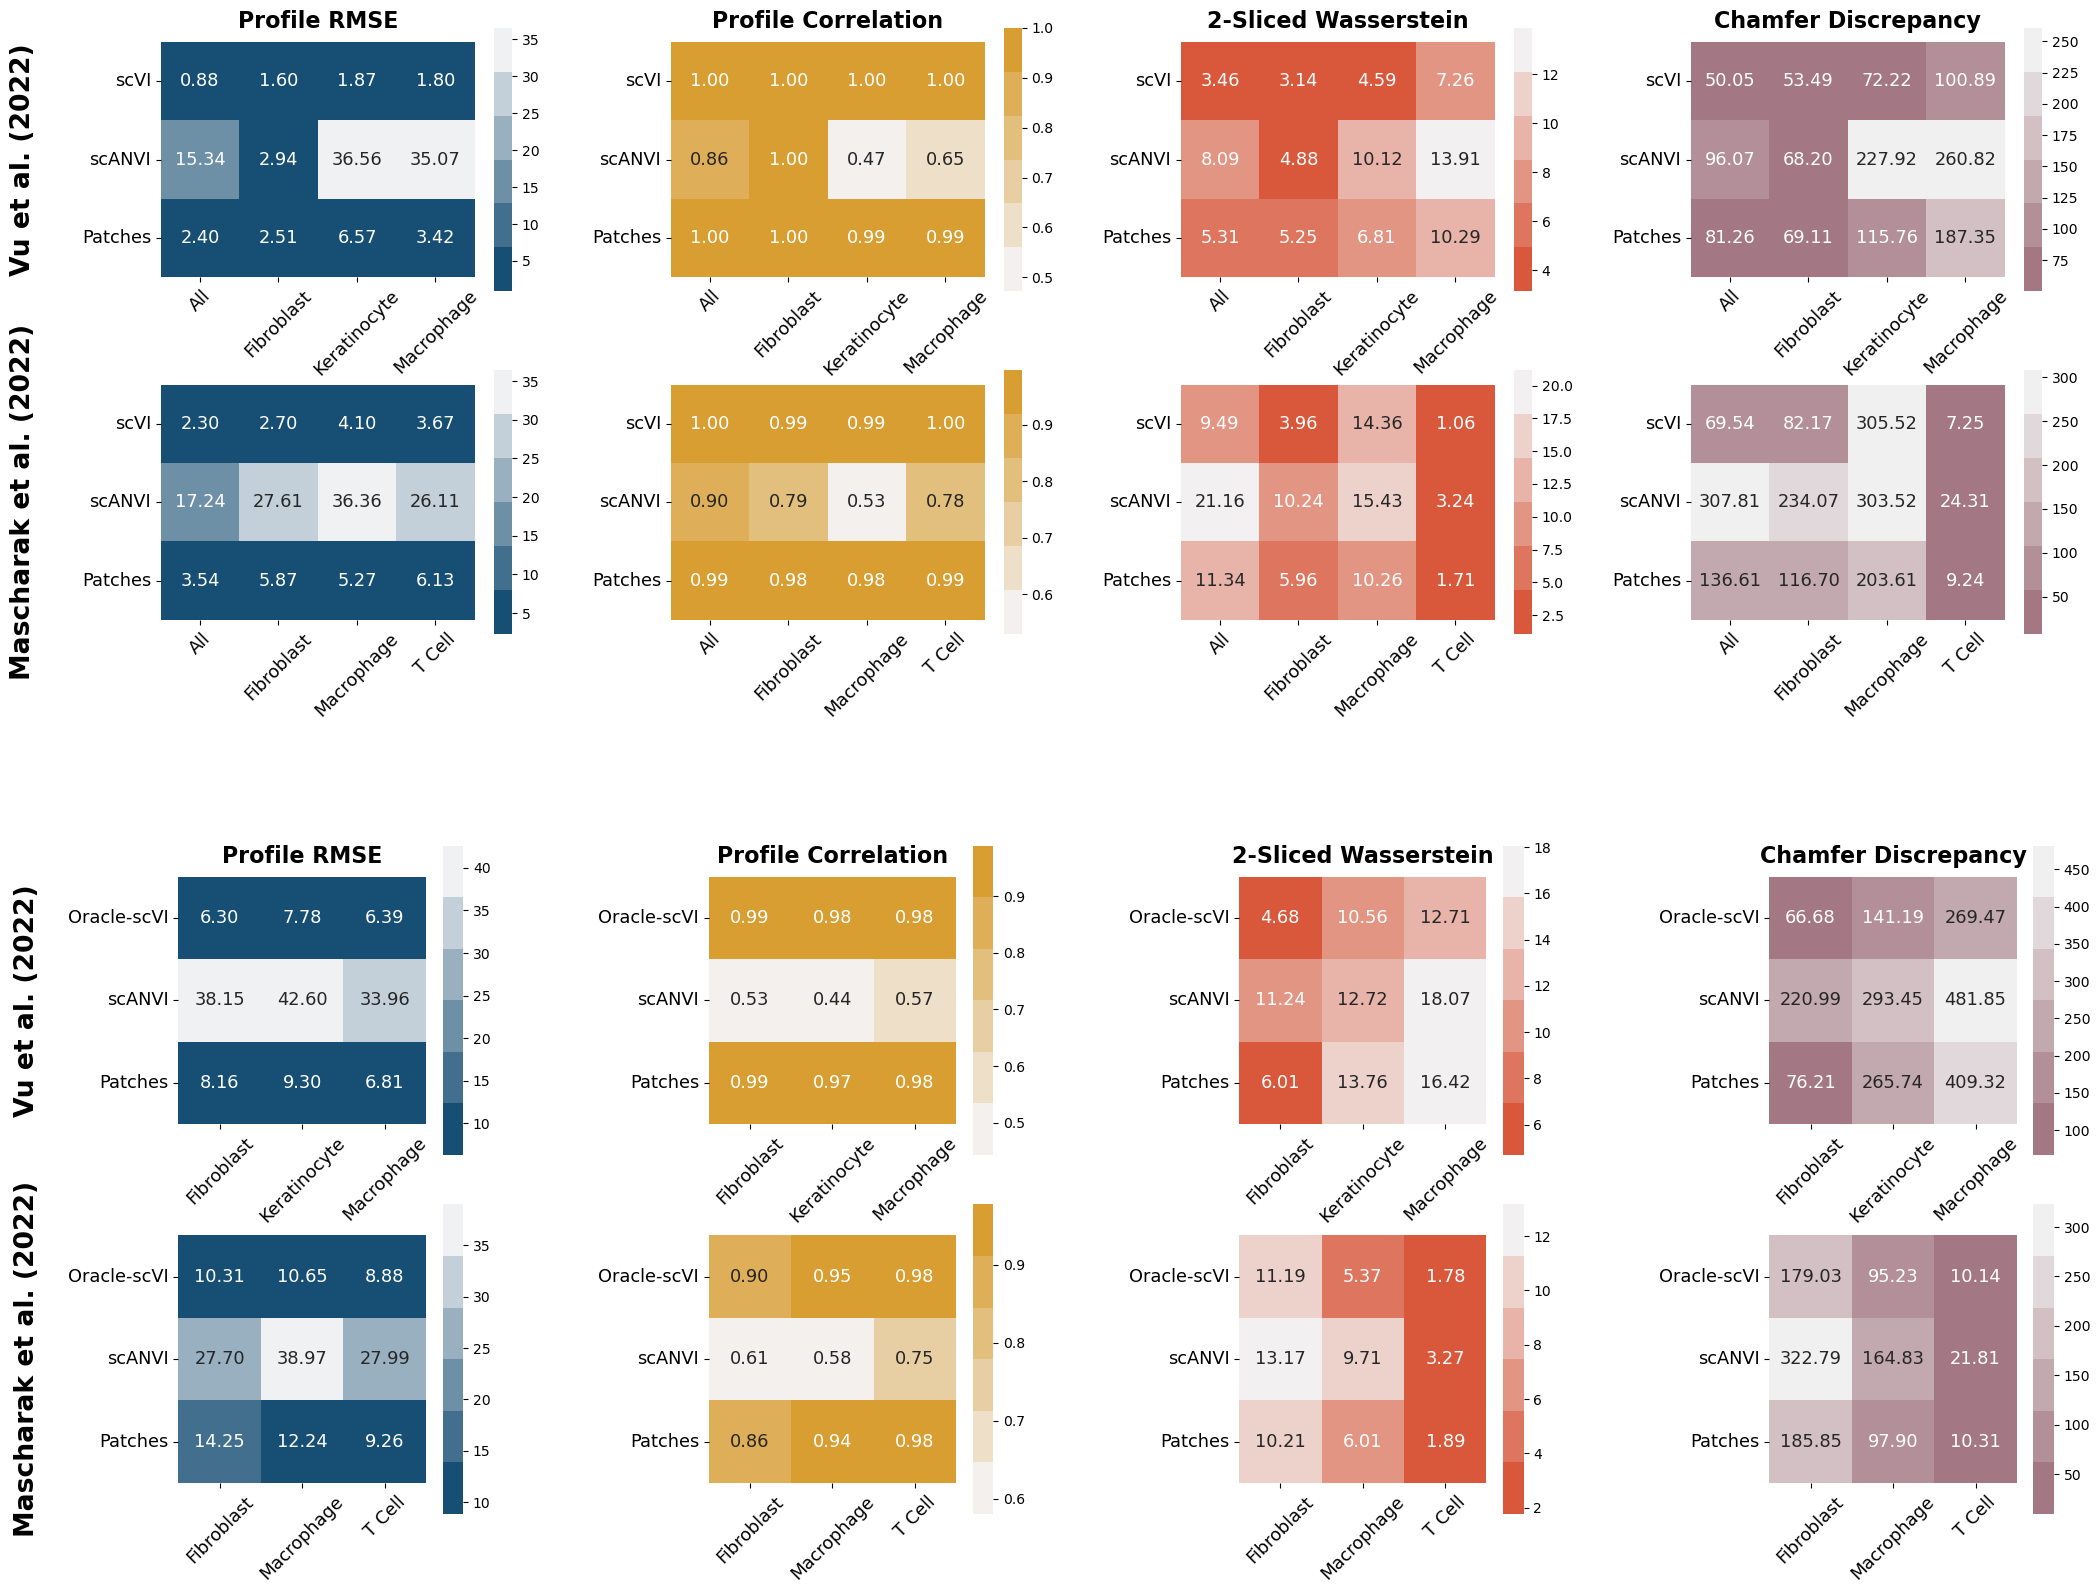

In [4]:
import matplotlib
plt.rcParams.update({'mathtext.default': 'regular' } ) 

fontsize=16
figscale = 3
leg_bbox = (0.5, 0.5)
models = ['scVI', 'scANVI', 'Patches']
model_labels_rec = ['scVI', 'scANVI', 'Patches']
model_labels_tr = ['Oracle-scVI', 'scANVI', 'Patches']
ct_vu = ['All', 'Fibroblast', 'Keratinocyte', 'Macrophage']
ct_mascharak = ['All', 'Fibroblast', 'Macrophage', 'T Cell']
fmt = '.2f'
shr=1
shr_fac=1.25

asp = 15

cmap_rmse = matplotlib.colors.ListedColormap(np.array(sns.light_palette('#164F73', reverse=True)))
cmap_corr = matplotlib.colors.ListedColormap(np.array(sns.light_palette('#D99E32')))
cmap_swd = matplotlib.colors.ListedColormap(np.array(sns.light_palette('#D9583B', reverse=True)))
cmap_cd = matplotlib.colors.ListedColormap(np.array(sns.light_palette('#A37784', reverse=True)))


# Fig grid
fig = plt.figure(figsize=(21 * 1/2.54 * figscale, 16 * 1/2.54 * figscale))
gs = gridspec.GridSpec(2, 1, hspace = 0.4, figure=fig, height_ratios=[5,5])
ax = [fig.add_subplot(gs[i//1, i%1]) for i in range(2)]
for axs in ax:
    axs.axis('off')

# Subfig grids
gs_rec = gridspec.GridSpecFromSubplotSpec(2,4,ax[0], hspace=0.3, wspace=0.30)
ax_rec = [fig.add_subplot(gs_rec[i//4, i%4]) for i in range(8)]

gs_tr = gridspec.GridSpecFromSubplotSpec(2,4,ax[1], hspace=0.45, wspace=0.60)
ax_tr = [fig.add_subplot(gs_tr[i//4, i%4]) for i in range(8)]




## RMSE
### Vu
res_rmse = np.array([float(elem.split('\\pm')[0][1:-1]) for ct in ct_vu for model in models for elem in metrics_res['Vu'][ct][model] ]).reshape(-1,4)[:,0].reshape(4,3).T
s = sns.heatmap(res_rmse, ax=ax_rec[0], cmap=cmap_rmse, annot=True, square=True, fmt=fmt, cbar_kws={"shrink": shr, 'aspect' : asp}, annot_kws={'fontsize' : fontsize * 0.8}) 
s.set_ylabel('Vu et al. (2022)', fontsize=fontsize * 1.2, weight='bold', labelpad=33)
ax_rec[0].set_xticklabels(ct_vu, rotation=45, fontsize=fontsize*0.8)
ax_rec[0].set_yticklabels(labels=model_labels_rec, rotation=0, fontsize=fontsize*0.8)
ax_rec[0].set_title('Profile RMSE', fontsize=fontsize, pad=10, weight='bold')

### Mascharak
res_rmse = np.array([float(elem.split('\\pm')[0][1:-1]) for ct in ct_mascharak for model in models for elem in metrics_res['Mascharak'][ct][model] ]).reshape(-1,4)[:,0].reshape(4,3).T
s = sns.heatmap(res_rmse, ax=ax_rec[4], cmap=cmap_rmse, annot=True, square=True, fmt=fmt, cbar_kws={"shrink": shr, 'aspect' : asp}, annot_kws={'fontsize' : fontsize * 0.8}) 
s.set_ylabel('Mascharak et al. (2022)', fontsize=fontsize * 1.2, weight='bold', labelpad=33)
ax_rec[4].set_xticklabels(ct_mascharak, rotation=45, fontsize=fontsize*0.8)
ax_rec[4].set_yticklabels(labels=model_labels_rec, rotation=0, fontsize=fontsize*0.8)


## Corr
### Vu
res_corr = np.array([float(elem.split('\\pm')[0][1:-1]) for ct in ct_vu for model in models for elem in metrics_res['Vu'][ct][model] ]).reshape(-1,4)[:,1].reshape(4,3).T
sns.heatmap(res_corr, ax=ax_rec[1], cmap=cmap_corr, annot=True, square=True, fmt=fmt, cbar_kws={"shrink": shr, 'aspect' : asp}, annot_kws={'fontsize' : fontsize * 0.8}) 
ax_rec[1].set_xticklabels(ct_vu, rotation=45, fontsize=fontsize*0.8)
ax_rec[1].set_yticklabels(labels=model_labels_rec, rotation=0, fontsize=fontsize*0.8)
ax_rec[1].set_title('Profile Correlation', fontsize=fontsize, pad=10, weight='bold')



### Mascharak
res_corr = np.array([float(elem.split('\\pm')[0][1:-1]) for ct in ct_mascharak for model in models for elem in metrics_res['Mascharak'][ct][model] ]).reshape(-1,4)[:,1].reshape(4,3).T
sns.heatmap(res_corr, ax=ax_rec[5], cmap=cmap_corr, annot=True, square=True, fmt=fmt, cbar_kws={"shrink": shr, 'aspect' : asp}, annot_kws={'fontsize' : fontsize * 0.8})
ax_rec[5].set_xticklabels(ct_mascharak, rotation=45, fontsize=fontsize*0.8)
ax_rec[5].set_yticklabels(labels=model_labels_rec, rotation=0, fontsize=fontsize*0.8)




## SWD
### Vu
res_swd = np.array([float(elem.split('\\pm')[0][1:-1]) for ct in ct_vu for model in models for elem in metrics_res['Vu'][ct][model] ]).reshape(-1,4)[:,2].reshape(4,3).T
sns.heatmap(res_swd, ax=ax_rec[2], cmap=cmap_swd, annot=True, square=True, fmt=fmt, cbar_kws={"shrink": shr, 'aspect' : asp}, annot_kws={'fontsize' : fontsize * 0.8})
ax_rec[2].set_xticklabels(ct_vu, rotation=45, fontsize=fontsize*0.8)
ax_rec[2].set_yticklabels(labels=model_labels_rec, rotation=0, fontsize=fontsize*0.8)
ax_rec[2].set_title('2-Sliced Wasserstein', fontsize=fontsize, pad=10, weight='bold')



### Mascharak
res_swd = np.array([float(elem.split('\\pm')[0][1:-1]) for ct in ct_mascharak for model in models for elem in metrics_res['Mascharak'][ct][model] ]).reshape(-1,4)[:,2].reshape(4,3).T
sns.heatmap(res_swd, ax=ax_rec[6], cmap=cmap_swd, annot=True, square=True, fmt=fmt, cbar_kws={"shrink": shr, 'aspect' : asp}, annot_kws={'fontsize' : fontsize * 0.8}) 
ax_rec[6].set_xticklabels(ct_mascharak, rotation=45, fontsize=fontsize*0.8)
ax_rec[6].set_yticklabels(labels=model_labels_rec, rotation=0, fontsize=fontsize*0.8)





## CD
### Vu
res_cd = np.array([float(elem.split('\\pm')[0][1:-1]) for ct in ct_vu for model in models for elem in metrics_res['Vu'][ct][model] ]).reshape(-1,4)[:,3].reshape(4,3).T
sns.heatmap(res_cd, ax=ax_rec[3], cmap=cmap_cd, annot=True, square=True, fmt=fmt, cbar_kws={"shrink": shr, 'aspect' : asp}, annot_kws={'fontsize' : fontsize * 0.8}) 
ax_rec[3].set_xticklabels(ct_vu, rotation=45, fontsize=fontsize * 0.8)
ax_rec[3].set_yticklabels(labels=model_labels_rec, rotation=0, fontsize=fontsize * 0.8)
ax_rec[3].set_title('Chamfer Discrepancy', fontsize=fontsize, pad=10, weight='bold')



### Mascharak
res_cd = np.array([float(elem.split('\\pm')[0][1:-1]) for ct in ct_mascharak for model in models for elem in metrics_res['Mascharak'][ct][model] ]).reshape(-1,4)[:,3].reshape(4,3).T
sns.heatmap(res_cd, ax=ax_rec[7], cmap=cmap_cd, annot=True, square=True, fmt=fmt, cbar_kws={"shrink": shr, 'aspect' : asp}, annot_kws={'fontsize' : fontsize * 0.8}) 
ax_rec[7].set_xticklabels(ct_mascharak, rotation=45, fontsize=fontsize * 0.8)
ax_rec[7].set_yticklabels(labels=model_labels_rec, rotation=0, fontsize=fontsize * 0.8)






# Transfer
ax_tr[0].set_ylabel('Vu et al. (2022)', fontsize=fontsize * 1.2, weight='bold')
ax_tr[4].set_ylabel('Mascharak et al. (2022)', fontsize=fontsize * 1.2, weight='bold')

## RMSE
### Vu
res_rmse = np.array([float(elem.split('\\pm')[0][1:-1]) for ct in ct_vu[1:] for model in models for elem in metrics_res_transfer['Vu'][ct][model] ]).reshape(-1,4)[:,0].reshape(3,3).T
s = sns.heatmap(res_rmse, ax=ax_tr[0], cmap=cmap_rmse, annot=True, square=True, fmt=fmt, cbar_kws={"shrink": shr*shr_fac, 'aspect' : asp}, annot_kws={'fontsize' : fontsize * 0.8})
s.set_ylabel('Vu et al. (2022)', fontsize=fontsize * 1.2, weight='bold', labelpad=20)
ax_tr[0].set_xticklabels(ct_vu[1:], rotation=45, fontsize=fontsize * 0.8)
ax_tr[0].set_yticklabels(labels=model_labels_tr, rotation=0, fontsize=fontsize * 0.8)
ax_tr[0].set_title('Profile RMSE', fontsize=fontsize, pad=10, weight='bold')


### Mascharak
res_rmse = np.array([float(elem.split('\\pm')[0][1:-1]) for ct in ct_mascharak[1:] for model in models for elem in metrics_res_transfer['Mascharak'][ct][model] ]).reshape(-1,4)[:,0].reshape(3,3).T
s = sns.heatmap(res_rmse, ax=ax_tr[4], cmap=cmap_rmse, annot=True, square=True, fmt=fmt, cbar_kws={"shrink": shr*shr_fac, 'aspect' : asp}, annot_kws={'fontsize' : fontsize * 0.8}) 
s.set_ylabel('Mascharak et al. (2022)', fontsize=fontsize * 1.2, weight='bold', labelpad=20)
ax_tr[4].set_xticklabels(ct_mascharak[1:], rotation=45, fontsize=fontsize * 0.8)
ax_tr[4].set_yticklabels(labels=model_labels_tr, rotation=0, fontsize=fontsize * 0.8)


## Corr
### Vu
res_corr = np.array([float(elem.split('\\pm')[0][1:-1]) for ct in ct_vu[1:] for model in models for elem in metrics_res_transfer['Vu'][ct][model] ]).reshape(-1,4)[:,1].reshape(3,3).T
sns.heatmap(res_corr, ax=ax_tr[1], cmap=cmap_corr, annot=True, square=True, fmt=fmt, cbar_kws={"shrink": shr*shr_fac, 'aspect' : asp},  annot_kws={'fontsize' : fontsize * 0.8}) 
ax_tr[1].set_xticklabels(ct_vu[1:], rotation=45, fontsize=fontsize * 0.8)
ax_tr[1].set_yticklabels(labels=model_labels_tr, rotation=0, fontsize=fontsize * 0.8)
ax_tr[1].set_title('Profile Correlation', fontsize=fontsize, pad=10, weight='bold')



### Mascharak
res_corr = np.array([float(elem.split('\\pm')[0][1:-1]) for ct in ct_mascharak[1:] for model in models for elem in metrics_res_transfer['Mascharak'][ct][model] ]).reshape(-1,4)[:,1].reshape(3,3).T
sns.heatmap(res_corr, ax=ax_tr[5], cmap=cmap_corr, annot=True, square=True, fmt=fmt, cbar_kws={"shrink": shr*shr_fac, "ticks" : np.linspace(0.6,1,5), 'aspect' : asp},  annot_kws={'fontsize' : fontsize * 0.8}) 
ax_tr[5].set_xticklabels(ct_mascharak[1:], rotation=45, fontsize=fontsize * 0.8)
ax_tr[5].set_yticklabels(labels=model_labels_tr, rotation=0, fontsize=fontsize * 0.8)





## SWD
### Vu
res_swd = np.array([float(elem.split('\\pm')[0][1:-1]) for ct in ct_vu[1:] for model in models for elem in metrics_res_transfer['Vu'][ct][model] ]).reshape(-1,4)[:,2].reshape(3,3).T
sns.heatmap(res_swd, ax=ax_tr[2], cmap=cmap_swd, annot=True, square=True, fmt=fmt, cbar_kws={"shrink": shr*shr_fac, 'aspect' : asp},  annot_kws={'fontsize' : fontsize * 0.8}) 
ax_tr[2].set_xticklabels(ct_vu[1:], rotation=45, fontsize=fontsize * 0.8)
ax_tr[2].set_yticklabels(labels=model_labels_tr, rotation=0, fontsize=fontsize * 0.8)
ax_tr[2].set_title('2-Sliced Wasserstein', fontsize=fontsize, pad=10, weight='bold')


### Mascharak
res_swd = np.array([float(elem.split('\\pm')[0][1:-1]) for ct in ct_mascharak[1:] for model in models for elem in metrics_res_transfer['Mascharak'][ct][model] ]).reshape(-1,4)[:,2].reshape(3,3).T
sns.heatmap(res_swd, ax=ax_tr[6], cmap=cmap_swd, annot=True, square=True, fmt=fmt, cbar_kws={"shrink": shr*shr_fac, 'aspect' : asp},  annot_kws={'fontsize' : fontsize * 0.8}) 
ax_tr[6].set_xticklabels(ct_mascharak[1:], rotation=45, fontsize=fontsize * 0.8)
ax_tr[6].set_yticklabels(labels=model_labels_tr, rotation=0, fontsize=fontsize * 0.8)





## CD
### Vu
res_cd = np.array([float(elem.split('\\pm')[0][1:-1]) for ct in ct_vu[1:] for model in models for elem in metrics_res_transfer['Vu'][ct][model] ]).reshape(-1,4)[:,3].reshape(3,3).T
sns.heatmap(res_cd, ax=ax_tr[3], cmap=cmap_cd, annot=True, square=True, fmt=fmt, cbar_kws={"shrink": shr*shr_fac, 'aspect' : asp},  annot_kws={'fontsize' : fontsize * 0.8}) 
ax_tr[3].set_xticklabels(ct_vu[1:], rotation=45, fontsize=fontsize * 0.8)
ax_tr[3].set_yticklabels(labels=model_labels_tr, rotation=0, fontsize=fontsize * 0.8)
ax_tr[3].set_title('Chamfer Discrepancy', fontsize=fontsize, pad=10, weight='bold')



### Mascharak
res_cd = np.array([float(elem.split('\\pm')[0][1:-1]) for ct in ct_mascharak[1:] for model in models for elem in metrics_res_transfer['Mascharak'][ct][model] ]).reshape(-1,4)[:,3].reshape(3,3).T
sns.heatmap(res_cd, ax=ax_tr[7], cmap=cmap_cd, annot=True, square=True, fmt=fmt, cbar_kws={"shrink": shr*shr_fac, 'aspect' : asp},  annot_kws={'fontsize' : fontsize * 0.8}) 
ax_tr[7].set_xticklabels(ct_mascharak[1:], rotation=45, fontsize=fontsize * 0.8)
ax_tr[7].set_yticklabels(labels=model_labels_tr, rotation=0, fontsize=fontsize * 0.8)






#ax[0].set_title('Reconstructions', fontsize=fontsize*1.2, weight='bold', y=1.1)
#ax[1].set_title(r'Transfers ($t_0 \rightarrow t_1$)', fontsize=fontsize*1.2, weight='bold', y=1.1)

plt.savefig('plots/final/fig_5_tables.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Counts Plot

In [310]:
# Minimal imports
from ladder.scripts import (
    CrossConditionWorkflow,
)  # Our workflow object to run the cross-conditional model
from ladder.data import distrib_dataset, get_data  # Explicit dataset setting
from ladder.scripts.metrics import _get_subset, _get_rmse_n_to_1, _get_corr_n_to_1, _get_chamf_n_to_1, _get_sliced_wasserstein_n_to_1, _get_normalized_profile, get_normalized_profile, get_reproduction_error


import anndata as ad
import pandas as pd
import numpy as np
import scanpy as sc
import os, sys, re, pickle

setname, model, subtype = (
    "ay",
    "SCANVI",
    None
)

print(f"Running: {setname}, {model}")

k = 5

results = {}

for num_iter in range(k):
    match setname:
        case "ay":
            # Load the anndata object
            anndata = ad.read_h5ad("data/vu_2022_ay_wh.h5ad")
            anndata.layers["normalized"] = anndata.X

            # Find/subset HVGs & swap to raw counts
            sc.pp.highly_variable_genes(
                anndata, n_top_genes=3000, batch_key="sample"
            )

            anndata = anndata[:, anndata.var["highly_variable"]]
            anndata.X = anndata.layers["counts"]

            factors = ["time", "age", "broad_type"]
            batch_key = "sample"

        case "mascharak":
            # Load the anndata object
            anndata = ad.read_h5ad("data/mascharak_2022_tn_wh.h5ad")
            anndata.layers["normalized"] = anndata.X

            # Find/subset HVGs & swap to raw counts
            sc.pp.highly_variable_genes(anndata, n_top_genes=3000)

            anndata = anndata[:, anndata.var["highly_variable"]]
            anndata.X = anndata.layers["counts"]

            factors = ["time", "treatment", "broad_type"]
            batch_key = None

    # Get workflow
    seed = int([re.match(fr'{model}_{setname}_{num_iter}_(\d+)', elem) for elem in os.listdir(fr'model_exps_recon/repeats/{model}_{setname}') if re.match(fr'{model}_{setname}_{num_iter}_(\d+)', elem) is not None][0][1])
    print(f"Seed is now {seed}")
    workflow = CrossConditionWorkflow(anndata, verbose=True, random_seed=seed)

    # Call prep_model once to load data initially
    workflow.prep_model(
        factors,
        batch_key=batch_key,
        cell_type_label_key="broad_type",
        model_type=model,
        optim_args={
            "lr": 1e-3,
        },
    )

    workflow.load_model(f'model_exps_recon/repeats/{model}_{setname}/{model}_{setname}_{num_iter}')


    # Grab specific cell type if so
    if subtype is not None:
        test_set = workflow._subset_by_type(subtype)
    else:
        test_set = workflow.test_set

    preds_mean_error, preds_mean_var, pred_profiles, preds = (
            get_reproduction_error(
                test_set,
                workflow.predictive,
                metric='rmse',
                n_trials=10,
                verbose=workflow.verbose,
                use_cuda=False,
                batched=workflow.batch_correction,
            )
        )

    if workflow.batch_correction: 
        counts_plot_mats = [(np.log1p(preds[0].mean(0)), np.log1p(test_set[:][0][:, :-1].mean(0))), (np.log1p(preds[0].var(0)), np.log1p(test_set[:][0][:, :-1].var(0)))]

    else:
         counts_plot_mats = [(np.log1p(preds[0].mean(0)), np.log1p(test_set[:][0][:, :].mean(0))), (np.log1p(preds[0].var(0)), np.log1p(test_set[:][0][:, :].var(0)))]
        

    if subtype == None:
        subtype = "All"

    with open(f'model_exps_recon/res/res_counts_{model}_{setname}_{subtype}', 'wb') as handle:
        pickle.dump(counts_plot_mats, handle, protocol=pickle.HIGHEST_PROTOCOL)

    break

Running: ay, SCANVI
Seed is now 789049


/insomnia001/depts/morpheus/users/ob2391/miniforge3/envs/csvae/lib/python3.12/site-packages/ladder/data/real_data.py:299: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  anndat.obs[colname] = anndat.obs[colname].astype("category")


Initialized workflow to run cross-condition model.

Condition classes : ['time', 'age', 'broad_type']
Number of attributes per class : [3, 2, 10]

Initialized SCANVI model.
Model arguments: {'reconstruction': 'ZINB', 'batch_correction': True, 'scale_factor': 2.6041666666666666e-06, 'num_labels': 60}

Optimizer args parsed successfully. Final arguments: {'optimizer': <class 'torch.optim.adam.Adam'>, 'optim_args': {'lr': 0.001, 'eps': 0.01, 'betas': (0.9, 0.999)}, 'gamma': 1, 'milestones': [10000000000.0]}


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:48<00:00,  4.82s/it]


In [17]:
counts_dict = {
    'Vu' : {
        'scVI' : None,
        'scANVI' : None,
        'Patches' : None,
    },

    'Mascharak' : {
        'scVI' : None,
        'scANVI' : None,
        'Patches' : None,
    }
}

for setname in ['ay', 'mascharak']:
    match setname :
        case 'ay':
            name = 'Vu'
            
        case 'mascharak':
            name = 'Mascharak'

    for model in ['Patches', 'SCVI', 'SCANVI']:
        with open(f'model_exps_recon/res/res_counts_{model}_{setname}_All', 'rb') as handle:
            f = pickle.load(handle)
            
            if model in ['SCVI', 'SCANVI']:
                modelname = model[:2].lower() + model[2:]
            else:
                modelname = model

            counts_dict[name][modelname] = f

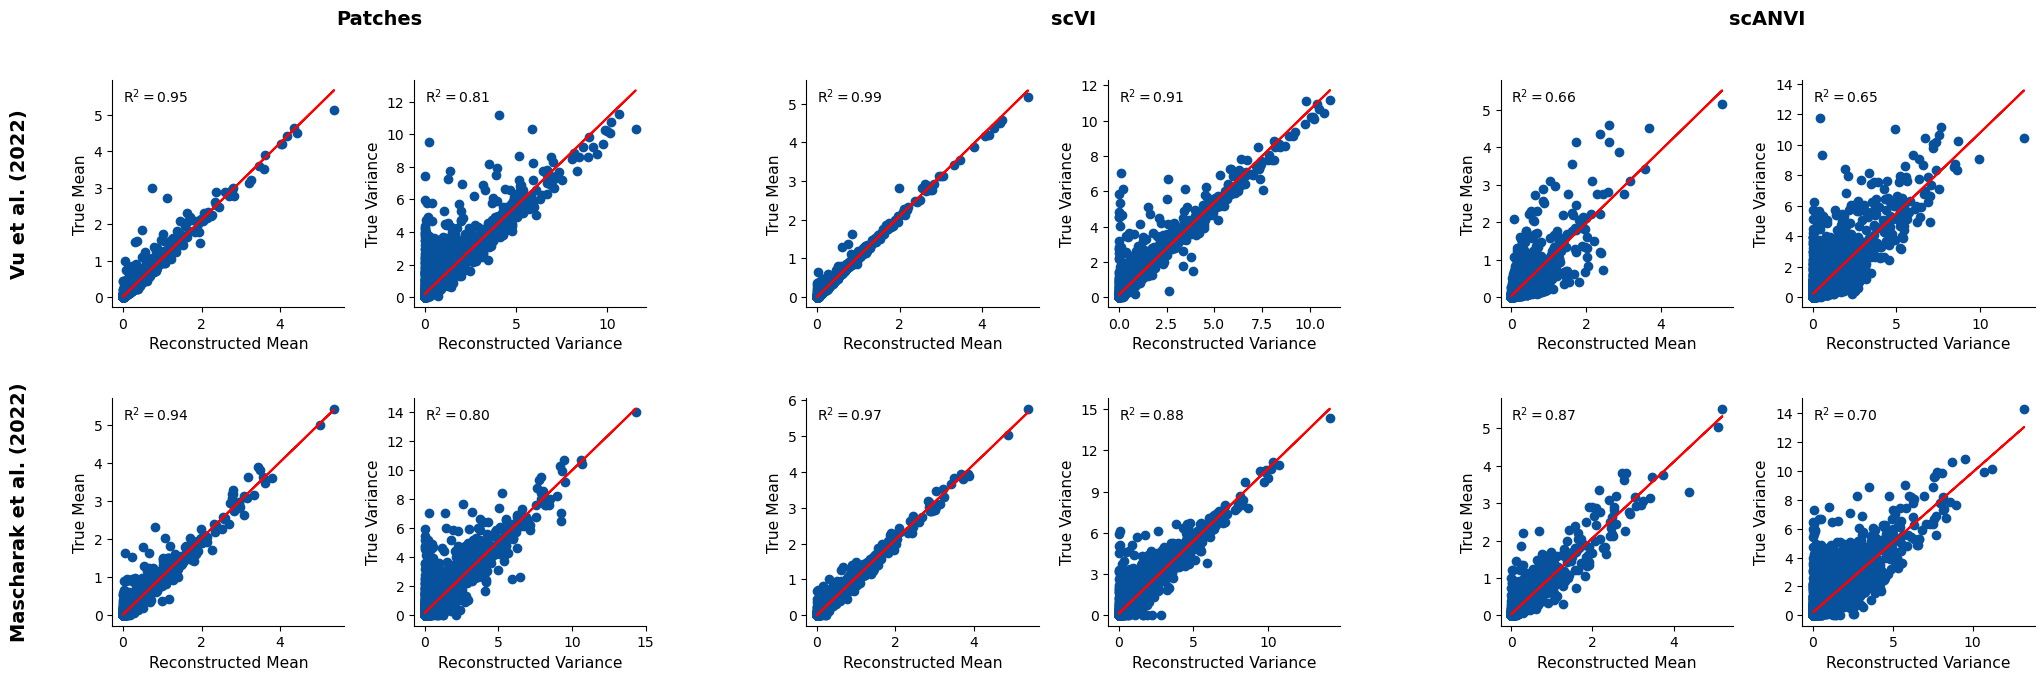

In [41]:
from scipy.stats import linregress
import matplotlib
plt.rcParams.update({'mathtext.default': 'regular' } ) 

y_offset = 0.03


# Courtesy of: https://stackoverflow.com/questions/7965743/how-can-i-set-the-aspect-ratio
def force_aspect(ax,aspect=1):
    im = ax.get_images()
    extent =  im[0].get_extent()
    ax.set_aspect(abs((extent[1]-extent[0])/(extent[3]-extent[2]))/aspect)


fontsize=14
figscale = 3
leg_bbox = (0.5, 0.5)


# Fig grid
fig = plt.figure(figsize=(21 * 1/2.54 * figscale, 6 * 1/2.54 * figscale))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.3)
ax = [fig.add_subplot(gs[i//3, i%3]) for i in range(6)]
for axs in ax:
    plt.setp(axs.spines.values(), visible=False)
    axs.tick_params(left=False, labelleft=False)
    axs.xaxis.set_visible(False)
    axs.patch.set_visible(False)

# Subfig grids
gs_inner = [gridspec.GridSpecFromSubplotSpec(1,2,ax[i], wspace=0.3) for i in range(6)]
ax_inner = [fig.add_subplot(gs_inner[i//2][i%2]) for i in range(12)]


# Patches
## Vu
### Mean
res = linregress(counts_dict['Vu']['Patches'][0][0], counts_dict['Vu']['Patches'][0][1])
ax_inner[0].scatter(counts_dict['Vu']['Patches'][0][0], counts_dict['Vu']['Patches'][0][1], color='#08519C')
ax_inner[0].plot(counts_dict['Vu']['Patches'][0][0], res.intercept + res.slope*counts_dict['Vu']['Patches'][0][0], 'r')
#ax_inner[0].set_aspect('equal')
ax_inner[0].annotate('$R^2 = {:.2f}$'.format(res.rvalue**2), xy=(0,ax_inner[0].get_ylim()[1] - y_offset * ax_inner[0].get_ylim()[1]), horizontalalignment='left', verticalalignment='top')
ax_inner[0].spines[['right', 'top']].set_visible(False)

### Var
res = linregress(counts_dict['Vu']['Patches'][1][0], counts_dict['Vu']['Patches'][1][1])
ax_inner[1].scatter(counts_dict['Vu']['Patches'][1][0], counts_dict['Vu']['Patches'][1][1], color='#08519C')
ax_inner[1].plot(counts_dict['Vu']['Patches'][1][0], res.intercept + res.slope*counts_dict['Vu']['Patches'][1][0], 'r')
#ax_inner[1].set_aspect('equal')
ax_inner[1].annotate('$R^2 = {:.2f}$'.format(res.rvalue**2), xy=(0 ,ax_inner[1].get_ylim()[1] - y_offset * ax_inner[1].get_ylim()[1]), horizontalalignment='left', verticalalignment='top')
ax_inner[1].spines[['right', 'top']].set_visible(False)

## Mascharak
res = linregress(counts_dict['Mascharak']['Patches'][0][0], counts_dict['Mascharak']['Patches'][0][1])
ax_inner[6].scatter(counts_dict['Mascharak']['Patches'][0][0], counts_dict['Mascharak']['Patches'][0][1], color='#08519C')
ax_inner[6].plot(counts_dict['Mascharak']['Patches'][0][0], res.intercept + res.slope*counts_dict['Mascharak']['Patches'][0][0], 'r')
#ax_inner[6].set_aspect('equal')
ax_inner[6].annotate('$R^2 = {:.2f}$'.format(res.rvalue**2), xy=(0,ax_inner[6].get_ylim()[1] - y_offset * ax_inner[6].get_ylim()[1]), horizontalalignment='left', verticalalignment='top')
ax_inner[6].spines[['right', 'top']].set_visible(False)

### Var
res = linregress(counts_dict['Mascharak']['Patches'][1][0], counts_dict['Mascharak']['Patches'][1][1])
ax_inner[7].scatter(counts_dict['Mascharak']['Patches'][1][0], counts_dict['Mascharak']['Patches'][1][1], color='#08519C')
ax_inner[7].plot(counts_dict['Mascharak']['Patches'][1][0], res.intercept + res.slope*counts_dict['Mascharak']['Patches'][1][0], 'r')
#ax_inner[7].set_aspect('equal')
ax_inner[7].annotate('$R^2 = {:.2f}$'.format(res.rvalue**2), xy=(0 ,ax_inner[7].get_ylim()[1] - y_offset * ax_inner[7].get_ylim()[1]), horizontalalignment='left', verticalalignment='top')
ax_inner[7].spines[['right', 'top']].set_visible(False)


# SCVI
## Vu
### Mean
res = linregress(counts_dict['Vu']['scVI'][0][0], counts_dict['Vu']['scVI'][0][1])
ax_inner[2].scatter(counts_dict['Vu']['scVI'][0][0], counts_dict['Vu']['scVI'][0][1], color='#08519C')
ax_inner[2].plot(counts_dict['Vu']['scVI'][0][0], res.intercept + res.slope*counts_dict['Vu']['scVI'][0][0], 'r')
#ax_inner[2].set_aspect('equal')
ax_inner[2].annotate('$R^2 = {:.2f}$'.format(res.rvalue**2), xy=(0,ax_inner[2].get_ylim()[1] - y_offset * ax_inner[2].get_ylim()[1]), horizontalalignment='left', verticalalignment='top')
ax_inner[2].spines[['right', 'top']].set_visible(False)

### Var
res = linregress(counts_dict['Vu']['scVI'][1][0], counts_dict['Vu']['scVI'][1][1])
ax_inner[3].scatter(counts_dict['Vu']['scVI'][1][0], counts_dict['Vu']['scVI'][1][1], color='#08519C')
ax_inner[3].plot(counts_dict['Vu']['scVI'][1][0], res.intercept + res.slope*counts_dict['Vu']['scVI'][1][0], 'r')
#ax_inner[3].set_aspect('equal')
ax_inner[3].annotate('$R^2 = {:.2f}$'.format(res.rvalue**2), xy=(0 ,ax_inner[3].get_ylim()[1] - y_offset * ax_inner[3].get_ylim()[1]), horizontalalignment='left', verticalalignment='top')
ax_inner[3].spines[['right', 'top']].set_visible(False)

## Mascharak
res = linregress(counts_dict['Mascharak']['scVI'][0][0], counts_dict['Mascharak']['scVI'][0][1])
ax_inner[8].scatter(counts_dict['Mascharak']['scVI'][0][0], counts_dict['Mascharak']['scVI'][0][1], color='#08519C')
ax_inner[8].plot(counts_dict['Mascharak']['scVI'][0][0], res.intercept + res.slope*counts_dict['Mascharak']['scVI'][0][0], 'r')
#ax_inner[8].set_aspect('equal')
ax_inner[8].annotate('$R^2 = {:.2f}$'.format(res.rvalue**2), xy=(0,ax_inner[8].get_ylim()[1] - y_offset * ax_inner[8].get_ylim()[1]), horizontalalignment='left', verticalalignment='top')
ax_inner[8].spines[['right', 'top']].set_visible(False)

### Var
res = linregress(counts_dict['Mascharak']['scVI'][1][0], counts_dict['Mascharak']['scVI'][1][1])
ax_inner[9].scatter(counts_dict['Mascharak']['scVI'][1][0], counts_dict['Mascharak']['scVI'][1][1], color='#08519C')
ax_inner[9].plot(counts_dict['Mascharak']['scVI'][1][0], res.intercept + res.slope*counts_dict['Mascharak']['scVI'][1][0], 'r')
#ax_inner[9].set_aspect('equal')
ax_inner[9].annotate('$R^2 = {:.2f}$'.format(res.rvalue**2), xy=(0 ,ax_inner[9].get_ylim()[1] - y_offset * ax_inner[9].get_ylim()[1]), horizontalalignment='left', verticalalignment='top')
ax_inner[9].set_yticks(np.linspace(0,15,6))
ax_inner[9].spines[['right', 'top']].set_visible(False)

# SCANVI
## Vu
### Mean
res = linregress(counts_dict['Vu']['scANVI'][0][0], counts_dict['Vu']['scANVI'][0][1])
ax_inner[4].scatter(counts_dict['Vu']['scANVI'][0][0], counts_dict['Vu']['scANVI'][0][1], color='#08519C')
ax_inner[4].plot(counts_dict['Vu']['scANVI'][0][0], res.intercept + res.slope*counts_dict['Vu']['scANVI'][0][0], 'r')
#ax_inner[4].set_aspect('equal')
ax_inner[4].annotate('$R^2 = {:.2f}$'.format(res.rvalue**2), xy=(0,ax_inner[4].get_ylim()[1] - y_offset * ax_inner[4].get_ylim()[1]), horizontalalignment='left', verticalalignment='top')
ax_inner[4].spines[['right', 'top']].set_visible(False)

### Var
res = linregress(counts_dict['Vu']['scANVI'][1][0], counts_dict['Vu']['scANVI'][1][1])
ax_inner[5].scatter(counts_dict['Vu']['scANVI'][1][0], counts_dict['Vu']['scANVI'][1][1], color='#08519C')
ax_inner[5].plot(counts_dict['Vu']['scANVI'][1][0], res.intercept + res.slope*counts_dict['Vu']['scANVI'][1][0], 'r')
#ax_inner[5].set_aspect('equal')
ax_inner[5].annotate('$R^2 = {:.2f}$'.format(res.rvalue**2), xy=(0 ,ax_inner[5].get_ylim()[1] - y_offset * ax_inner[5].get_ylim()[1]), horizontalalignment='left', verticalalignment='top')
ax_inner[5].spines[['right', 'top']].set_visible(False)

## Mascharak
res = linregress(counts_dict['Mascharak']['scANVI'][0][0], counts_dict['Mascharak']['scANVI'][0][1])
ax_inner[10].scatter(counts_dict['Mascharak']['scANVI'][0][0], counts_dict['Mascharak']['scANVI'][0][1], color='#08519C')
ax_inner[10].plot(counts_dict['Mascharak']['scANVI'][0][0], res.intercept + res.slope*counts_dict['Mascharak']['scANVI'][0][0], 'r')
#ax_inner[10].set_aspect('equal')
ax_inner[10].annotate('$R^2 = {:.2f}$'.format(res.rvalue**2), xy=(0,ax_inner[10].get_ylim()[1] - y_offset * ax_inner[10].get_ylim()[1]), horizontalalignment='left', verticalalignment='top')
ax_inner[10].spines[['right', 'top']].set_visible(False)

### Var
res = linregress(counts_dict['Mascharak']['scANVI'][1][0], counts_dict['Mascharak']['scANVI'][1][1])
ax_inner[11].scatter(counts_dict['Mascharak']['scANVI'][1][0], counts_dict['Mascharak']['scANVI'][1][1], color='#08519C')
ax_inner[11].plot(counts_dict['Mascharak']['scANVI'][1][0], res.intercept + res.slope*counts_dict['Mascharak']['scANVI'][1][0], 'r')
#ax_inner[11].set_aspect('equal')
ax_inner[11].annotate('$R^2 = {:.2f}$'.format(res.rvalue**2), xy=(0 ,ax_inner[11].get_ylim()[1] - y_offset * ax_inner[11].get_ylim()[1]), horizontalalignment='left', verticalalignment='top')
ax_inner[11].spines[['right', 'top']].set_visible(False)



# Titles
for i in range(0,12,2):
    ax_inner[i].set_ylabel('True Mean', fontsize=fontsize*0.8)
    ax_inner[i].set_xlabel('Reconstructed Mean', fontsize=fontsize*0.8)

for i in range(1,12,2):
    ax_inner[i].set_ylabel('True Variance', fontsize=fontsize*0.8)
    ax_inner[i].set_xlabel('Reconstructed Variance', fontsize=fontsize*0.8)


ax[0].set_ylabel('Vu et al. (2022)', fontsize=fontsize, weight='bold', labelpad=60)
ax[3].set_ylabel('Mascharak et al. (2022)', fontsize=fontsize, weight='bold', labelpad=60)


ax[0].set_title('Patches', fontsize=fontsize, weight='bold', pad=40)
ax[1].set_title('scVI', fontsize=fontsize, weight='bold', pad=40)
ax[2].set_title('scANVI', fontsize=fontsize, weight='bold', pad=40)



plt.savefig('plots/final/fig_5_counts_fig.png', dpi=300, bbox_inches='tight')
plt.show()